 → **Fahim Abrar Chowdhury**


 → **asamifahim007@gmail.com**

In [42]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix 
from sklearn.tree import DecisionTreeClassifier
from  sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Dataset Load

In [3]:
df = pd.read_csv("Heart_disease_prediction.csv")
df.head() # see the first 5 column of this dataset

,"""""",Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


# Let`s identify the columns name


-> **RestBP**  -Resting BP


-> **Chol**   -Cholesterol Level


-> **Fbs**     -Fasting Blood Pressure 


-> **RestECG** -Resting ECG Result


-> **MaxHR**   -Maximum Heartrate achived


-> **ExAng**   -Excercise induced angina ( 1 - Yes and 0 - No)


-> **Oldpeak** -Excercise time ST depression value


-> **Slope**   -Peak Excercise ST Segment slope


-> **Ca**      -Major vessels


-> **Thal**    -Thalassemia Type


-> **AHD**     -Heart Disease

In [4]:
df.tail() # see the last 5 column of this dataset

,"""""",Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
298,299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,302,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes
302,303,38,1,nonanginal,138,175,0,0,173,0,0.0,1,NaN,normal,No


In [5]:
df.shape # dataset shape it`s indicate how many rows and columns present in this dataset

(303, 15)

In [6]:
df.info() # it`s shows the data type of all columns 

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0    ""        303 non-null    int64  
 1   Age        303 non-null    int64  
 2   Sex        303 non-null    int64  
 3   ChestPain  303 non-null    str    
 4   RestBP     303 non-null    int64  
 5   Chol       303 non-null    int64  
 6   Fbs        303 non-null    int64  
 7   RestECG    303 non-null    int64  
 8   MaxHR      303 non-null    int64  
 9   ExAng      303 non-null    int64  
 10  Oldpeak    303 non-null    float64
 11  Slope      303 non-null    int64  
 12  Ca         299 non-null    float64
 13  Thal       301 non-null    str    
 14  AHD        303 non-null    str    
dtypes: float64(2), int64(10), str(3)
memory usage: 35.6 KB


In this dataset , notice there are 2 column are float , 10 are int and rest of them are string 

In [7]:
df.describe()

,"""""",Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000
mean,152.000000,54.438944,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241
std,87.612784,9.038662,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438
min,1.000000,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,76.500000,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,152.000000,56.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,227.500000,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000
max,303.000000,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000


In [8]:
df.columns

Index([' ""', 'Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG',
       'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD'],
      dtype='str')

In [9]:
df['Thal'].unique()

<StringArray>
['fixed', 'normal', 'reversable', nan]
Length: 4, dtype: str

In [10]:
df['Thal'].value_counts()

Thal
normal        166
reversable    117
fixed          18
Name: count, dtype: int64

In [11]:
df['Thal'] = df['Thal'].fillna(df['Thal'].mode()[0])

# Data pre processing

In [12]:
df.isna().sum() # Find out the nan values of this dataset

 ""          0
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         0
AHD          0
dtype: int64

In this dataset there are 2 column that has nan values which is CA and Thal 

In [13]:
df['Ca'] = df['Ca'].fillna(df['Ca'].mean()) #Handling those nan values Using mean 

In [14]:
df.duplicated().sum() # there is no duplicate values present in this dataset

np.int64(0)

# Exploratory Data Analysis (EDA)

<Axes: >

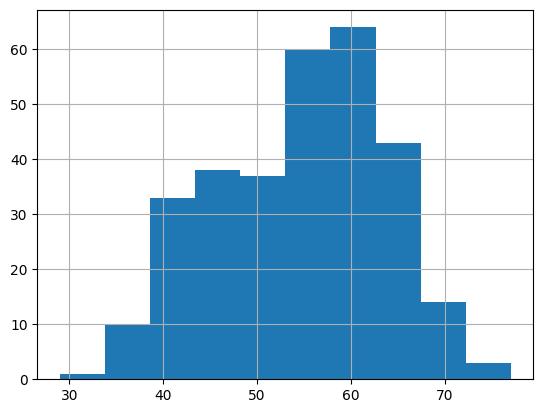

In [15]:
df['Age'].hist()

<Axes: xlabel='Sex', ylabel='count'>

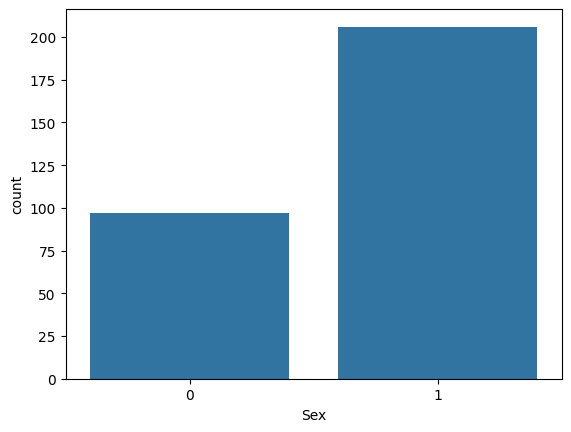

In [16]:
df['Sex'].value_counts()
sns.countplot(x='Sex', data=df)

<Axes: xlabel='AHD', ylabel='count'>

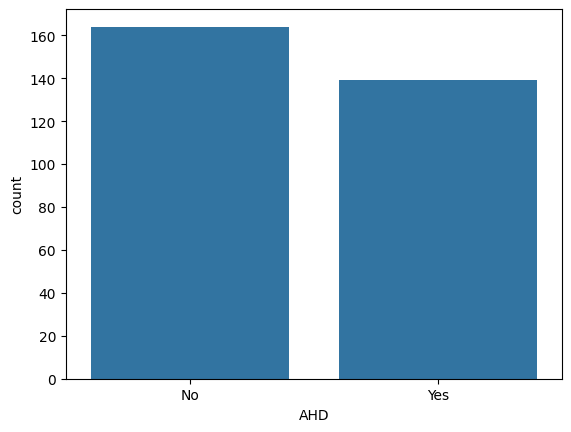

In [17]:
a = df['AHD'].value_counts() 
sns.countplot(x="AHD", data=df)

Text(0.5, 1.0, 'Gender wise Heart Disease')

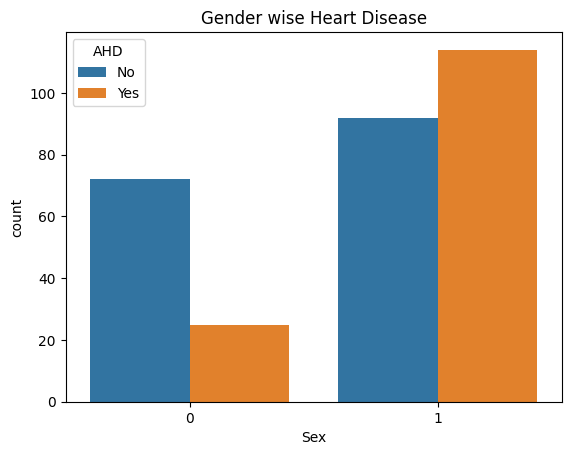

In [18]:
sns.countplot(x='Sex', hue='AHD', data=df)
plt.title("Gender wise Heart Disease")

Text(0.5, 1.0, 'Gender VS Heart Disease')

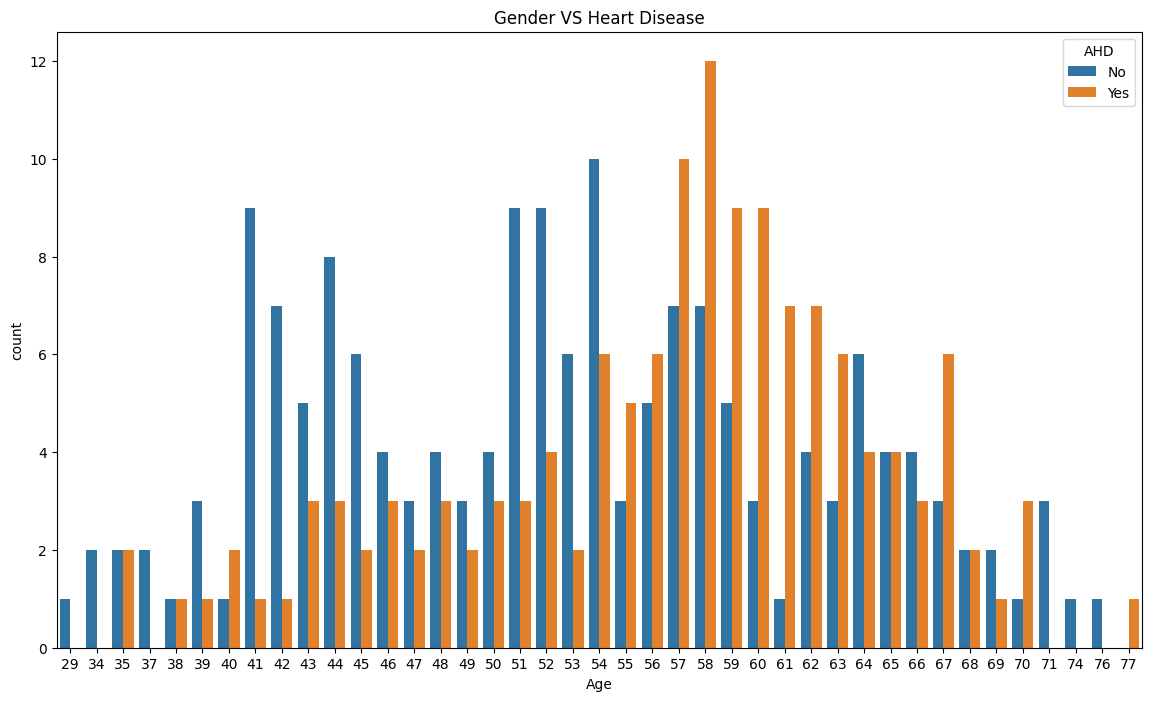

In [19]:
plt.figure(figsize=(14,8))
sns.countplot(x='Age', hue='AHD', data=df )
plt.title("Gender VS Heart Disease")

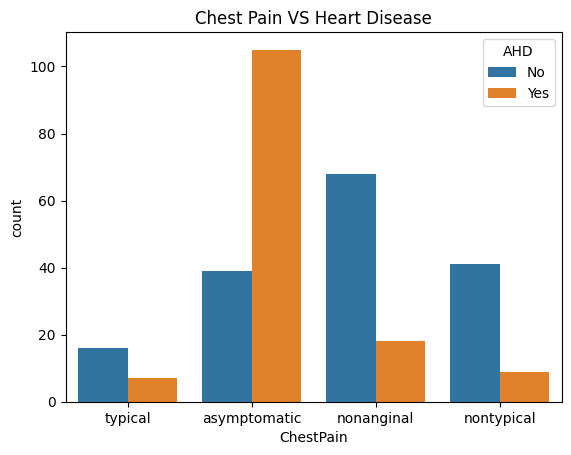

In [20]:
sns.countplot(x='ChestPain', hue='AHD', data=df)
plt.title("Chest Pain VS Heart Disease")
plt.show()

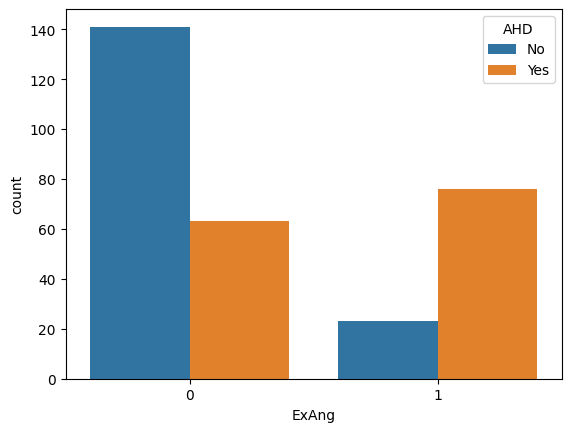

In [21]:
sns.countplot(x='ExAng', hue='AHD', data=df)
plt.show()

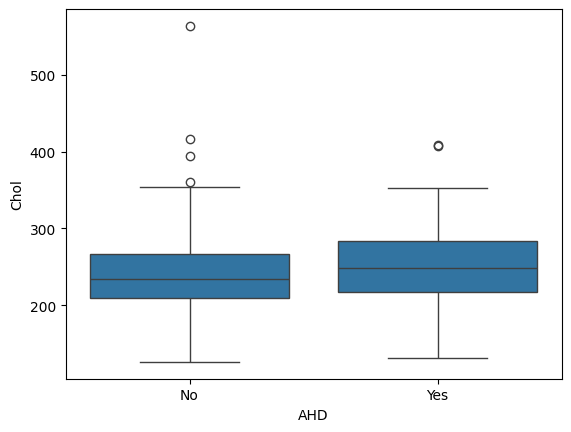

In [22]:
sns.boxplot(x='AHD', y='Chol', data=df)
plt.show()

<Axes: >

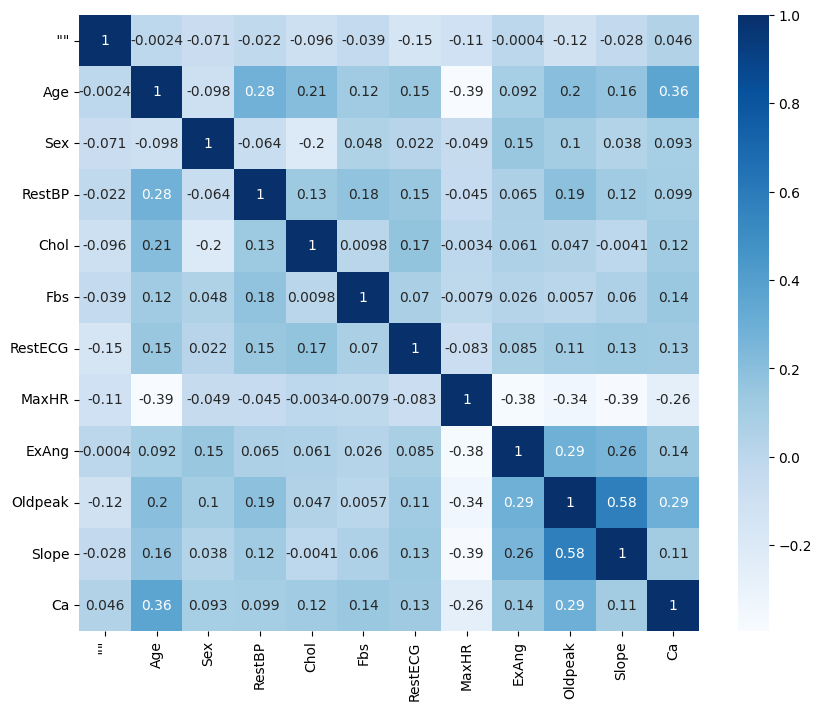

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')

# Dataset  Spliting

In [24]:
x = df.drop(['AHD'], axis=1)
y = df['AHD']


# Applying Encoding

In [25]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0    ""        303 non-null    int64  
 1   Age        303 non-null    int64  
 2   Sex        303 non-null    int64  
 3   ChestPain  303 non-null    str    
 4   RestBP     303 non-null    int64  
 5   Chol       303 non-null    int64  
 6   Fbs        303 non-null    int64  
 7   RestECG    303 non-null    int64  
 8   MaxHR      303 non-null    int64  
 9   ExAng      303 non-null    int64  
 10  Oldpeak    303 non-null    float64
 11  Slope      303 non-null    int64  
 12  Ca         303 non-null    float64
 13  Thal       303 non-null    str    
dtypes: float64(2), int64(10), str(2)
memory usage: 33.3 KB


In [26]:
# Chest_pain , Thal 
df['ChestPain'].unique()

<StringArray>
['typical', 'asymptomatic', 'nonanginal', 'nontypical']
Length: 4, dtype: str

In [27]:
# Using LabelEncoder

le = LabelEncoder()

x['ChestPain'] = le.fit_transform(x['ChestPain'])
x['Thal'] =le.fit_transform(x['Thal'])

In [28]:
y = le.fit_transform(y)

In [29]:
x.head()

,"""""",Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
0,1,63,1,3,145,233,1,2,150,0,2.3,3,0.0,0
1,2,67,1,0,160,286,0,2,108,1,1.5,2,3.0,1
2,3,67,1,0,120,229,0,2,129,1,2.6,2,2.0,2
3,4,37,1,1,130,250,0,0,187,0,3.5,3,0.0,1
4,5,41,0,2,130,204,0,2,172,0,1.4,1,0.0,1


After using encoding on ChestPain column ... typical , asymtomatic ,  nonanginal and nontypical all these are replace by 0,1,2,3 ...where 

**0** indicate Asymtomatic 

**1** indicate Nonanginal 

**2** indicate Nontypical 

**3** indicate Typical

# Using Train_Test_Split 

In [30]:
x_train , x_test , y_train, y_test = train_test_split(x,y, test_size=.2 , random_state=42)

# Applying Scaler

In [31]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

# Train and Test model including Model Evaluation using ***Logistic Regression***

Training Score  84.71074380165288


Test Score :  88.52459016393442


Accuray Score :  0.8852459016393442


Classification Report :                precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.90      0.88      0.89        32

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61





c:\Users\INTEL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Axes: >

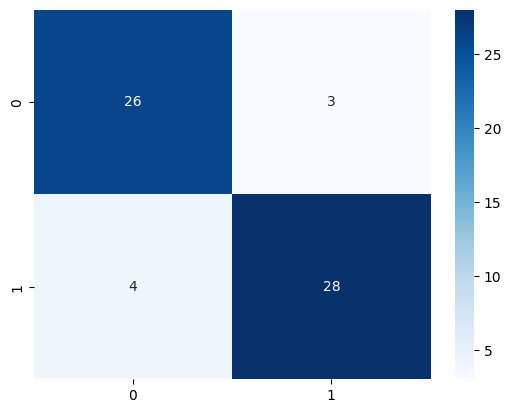

In [ ]:
lr = LogisticRegression() 

# Train Model 

model1 = lr.fit(x_train,y_train)
print("Training Score ", model1.score(x_train, y_train)* 100)
print("\n")


# Test model 
print("Test Score : ", model1.score(x_test,y_test)*100)
print("\n")


# Predictin for Model1
pred_1 = lr.predict(x_test)



# Model Evaluation


#Accuracy score
ac_score_lr = accuracy_score(y_test, pred_1)
print("Accuray Score : ", ac_score_lr) 
print("\n")


# classification report
clas_rep =classification_report(y_test, pred_1)
print("Classification Report : " , clas_rep)
print("\n")


# confusio matrix
con_max = confusion_matrix(y_test,pred_1)

sns.heatmap(con_max, annot=True, cmap="Blues")

# Performance Summary of → Logistic Regreesion 

**Training Score**  - **84.71074380165288**

**Training Score**  - **88.52459016393442**


**Accuray Score**  - **0.8852459016393442**

**Classification Report**

| Class | Precision | Recall | F1-score | Support |
|------|-----------|--------|----------|----------|
| No   | 0.87      | 0.90   | 0.89     | 29       |
| Yes  | 0.90      | 0.88   | 0.89     | 32       |

**After using Logistic Regression, the model performed well on the test/unseen data, which indicates good generalization and makes it suitable for building a reliable prediction model.**


# Train and Test model including Model Evaluation using ***Random Forest Classifier***

Training Score  100.0


Test Score :  86.88524590163934


Accuray Score :  0.8688524590163934


Classification Report :                precision    recall  f1-score   support

           0       0.82      0.93      0.87        29
           1       0.93      0.81      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61





<Axes: >

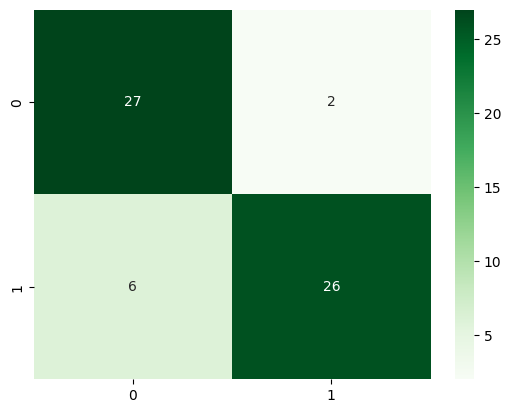

In [33]:
rf = RandomForestClassifier()

# Train Model 

model2 = rf.fit(x_train,y_train)
print("Training Score ", model2.score(x_train, y_train)* 100)
print("\n")


# Test model 
print("Test Score : ", model2.score(x_test,y_test)*100)
print("\n")


# Predictin for Model2
pred_2 = rf.predict(x_test)



# Model Evaluation


#Accuracy score
ac_score_rf = accuracy_score(y_test, pred_2)
print("Accuray Score : ", ac_score_rf) 
print("\n")


# classification report
clas_rep_rf =classification_report(y_test, pred_2)
print("Classification Report : " , clas_rep_rf)
print("\n")


# confusio matrix
con_max = confusion_matrix(y_test,pred_2)

sns.heatmap(con_max, annot=True, cmap="Greens")

# Performance Summary of → Random Forest Classifier

**Training Score**  - **100.0**

**Training Score**  - **86.88524590163934**


**Accuray Score**  - **86.88524590163934**

**Classification Report**

| Class | Precision | Recall | F1-score | Support |
|------|-----------|--------|----------|----------|
| No   | 0.82      | 0.93   | 0.87     | 29       |
| Yes  | 0.93      | 0.81   | 0.87     | 32       |

**After using Random Forest, the training accuracy was higher than the testing accuracy, which indicates that the model is overfitted.**



# Train and Test model including Model Evaluation using ***Decision Tree Classifier***

Training Score  100.0


Test Score :  81.9672131147541


Accuray Score :  0.8688524590163934


Classification Report :                precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61





<Axes: >

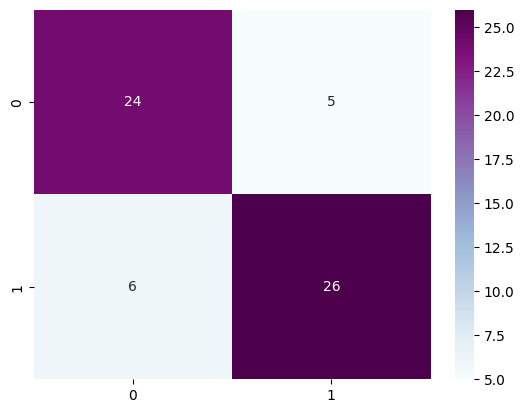

In [34]:
dt = DecisionTreeClassifier()

# Train Model 

model3 = dt.fit(x_train,y_train)
print("Training Score ", model3.score(x_train, y_train)* 100)
print("\n")


# Test model 
print("Test Score : ", model3.score(x_test,y_test)*100)
print("\n")


# Predictin for Model1
pred_3 = dt.predict(x_test)



# Model Evaluation


#Accuracy score
ac_score_dt = accuracy_score(y_test, pred_3)
print("Accuray Score : ", ac_score_rf) 
print("\n")


# classification report
clas_rep_rf =classification_report(y_test, pred_3)
print("Classification Report : " , clas_rep_rf)
print("\n")


# confusio matrix
con_max = confusion_matrix(y_test,pred_3)

sns.heatmap(con_max, annot=True, cmap="BuPu")

# Performance Summary of → Decision Tree Classifier 

**Training Score**  - **100.0**

**Training Score**  - **81.9672131147541**


**Accuray Score**  - **0.8688524590163934**

**Classification Report**

| Class | Precision | Recall | F1-score | Support |
|------|-----------|--------|----------|----------|
| No   | 0.78      | 0.86   | 0.82     | 29       |
| Yes  | 0.86      | 0.78   | 0.82     | 32       |

**After using Decision Tree Classifier, the training accuracy was higher than the testing accuracy, which indicates that the model is overfitted.**


# Train and Test model including Model Evaluation using ***XG Boost***

Training Score  100.0


Test Score :  88.52459016393442


Accuray Score :  0.8852459016393442


Classification Report :                precision    recall  f1-score   support

           0       0.87      0.90      0.88        29
           1       0.90      0.88      0.89        32

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61





<Axes: >

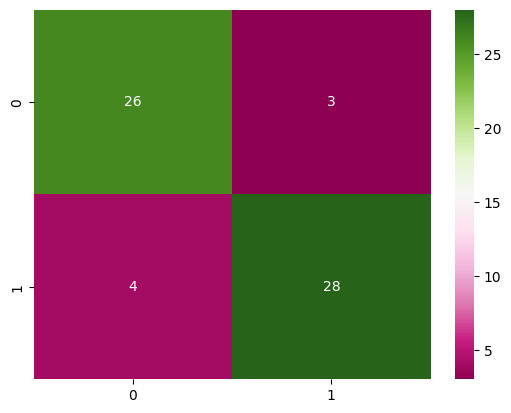

In [35]:
xg = XGBClassifier()

# Train Model 

model4 = xg.fit(x_train,y_train)
print("Training Score ", model4.score(x_train, y_train)* 100)
print("\n")


# Test model 
print("Test Score : ", model4.score(x_test,y_test)*100)
print("\n")


# Predictin for Model1
pred_4 = xg.predict(x_test)



# Model Evaluation


#Accuracy score
ac_score_xg = accuracy_score(y_test, pred_4)
print("Accuray Score : ", ac_score_xg) 
print("\n")


# classification report
clas_rep_xg =classification_report(y_test, pred_4)
print("Classification Report : " , clas_rep_xg)
print("\n")


# confusio matrix
con_max = confusion_matrix(y_test,pred_4)

sns.heatmap(con_max, annot=True, cmap="PiYG")


# Performance Summary of → XG Boost  

**Training Score**  - **100.0**

**Training Score**  - **88.52459016393442**


**Accuray Score**  - **0.8852459016393442**

**Classification Report**

| Class | Precision | Recall | F1-score | Support |
|------|-----------|--------|----------|----------|
| No   | 0.87      | 0.90   | 0.88     | 29       |
| Yes  | 0.90      | 0.88   | 0.89     | 32       |

**After using XG Boost, the training accuracy was higher than the testing accuracy, which indicates that the model is overfitted.**



# Train and Test model including Model Evaluation using ***Ann(Artificial Neural Network)***

Training Score  86.77685950413223


Test Score :  85.24590163934425


Accuray Score :  0.8524590163934426


Classification Report :                precision    recall  f1-score   support

           0       0.79      0.93      0.86        29
           1       0.93      0.78      0.85        32

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61





<Axes: >

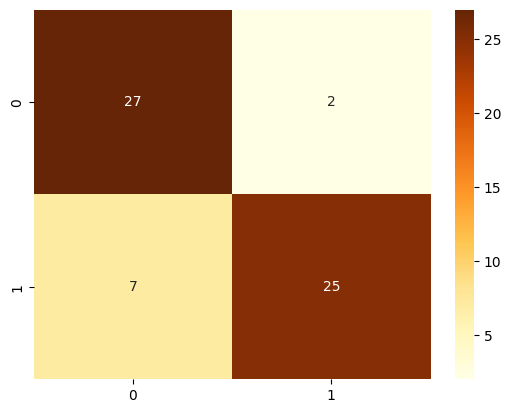

In [36]:
ann = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)

# Train Model 

model5 = ann.fit(x_train,y_train)
print("Training Score ", model5.score(x_train, y_train)* 100)
print("\n")


# Test model 
print("Test Score : ", model5.score(x_test,y_test)*100)
print("\n")


# Predictin for Model1
pred_5 =ann.predict(x_test)



# Model Evaluation


#Accuracy score
ac_score_ann = accuracy_score(y_test, pred_5)
print("Accuray Score : ", ac_score_ann) 
print("\n")


# classification report
clas_rep_ann =classification_report(y_test, pred_5)
print("Classification Report : " , clas_rep_ann)
print("\n")


# confusio matrix
con_max = confusion_matrix(y_test,pred_5)

sns.heatmap(con_max, annot=True, cmap="YlOrBr")


# Performance Summary of → ANN(Artificial Neural Network)

**Training Score**  - **86.77685950413223**

**Training Score**  - **85.24590163934425**


**Accuray Score**  - **0.8524590163934426**

**Classification Report**

| Class | Precision | Recall | F1-score | Support |
|------|-----------|--------|----------|----------|
| No   | 0.79      | 0.93   | 0.86     | 29       |
| Yes  | 0.93      | 0.78   | 0.85     | 32       |

**After using ANN(Artificial Neural Network), the model achieved 86% training accuracy and 85% test accuracy, which indicates good generalization with no significant overfitting**



# Train and Test model including Model Evaluation using ***SVM (Support Vector Classifier)***

Training Score  62.8099173553719


Test Score :  63.934426229508205


Accuray Score :  0.639344262295082


Classification Report :                precision    recall  f1-score   support

           0       0.58      0.86      0.69        29
           1       0.78      0.44      0.56        32

    accuracy                           0.64        61
   macro avg       0.68      0.65      0.63        61
weighted avg       0.68      0.64      0.62        61





<Axes: >

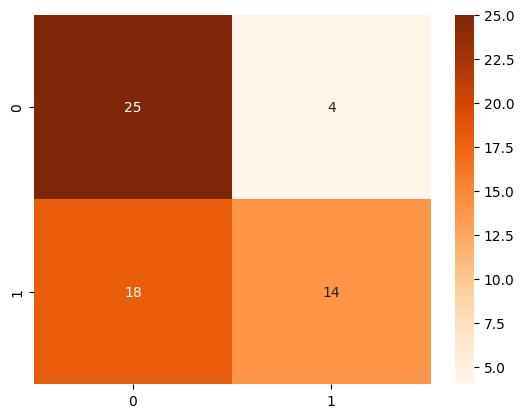

In [37]:
svc = SVC()

# Train Model 

model6 = svc.fit(x_train,y_train)
print("Training Score ", model6.score(x_train, y_train)* 100)
print("\n")


# Test model 
print("Test Score : ", model6.score(x_test,y_test)*100)
print("\n")


# Predictin for Model1
pred_6 =svc.predict(x_test)



# Model Evaluation


#Accuracy score
ac_score_svc = accuracy_score(y_test, pred_6)
print("Accuray Score : ", ac_score_svc) 
print("\n")


# classification report
clas_rep_svc =classification_report(y_test, pred_6)
print("Classification Report : " , clas_rep_svc)
print("\n")


# confusio matrix
con_max = confusion_matrix(y_test,pred_6)

sns.heatmap(con_max, annot=True, cmap="Oranges")


# Performance Summary of → SVC(Support Vector Classifier)

**Training Score**  - **62.8099173553719**

**Training Score**  - **63.934426229508205**


**Accuray Score**  - **0.639344262295082**

**Classification Report**

| Class | Precision | Recall | F1-score | Support |
|------|-----------|--------|----------|----------|
| No   | 0.58      | 0.86   | 0.69     | 29       |
| Yes  | 0.78      | 0.44   | 0.56     | 32       |

**After using SVC(Support Vector Classifier), the model achieved 62% training accuracy and 63% test accuracy, indicating low performance and possible underfitting.**


# Train and Test model including Model Evaluation using ***Naive Bayes***

Training Score  85.12396694214877


Test Score :  83.60655737704919


Accuray Score :  0.8360655737704918


Classification Report :                precision    recall  f1-score   support

           0       0.79      0.90      0.84        29
           1       0.89      0.78      0.83        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61





<Axes: >

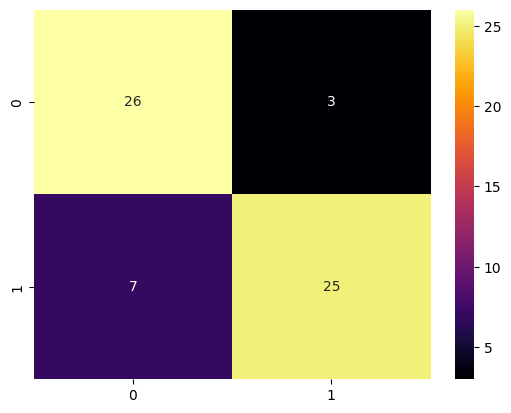

In [38]:
nb = GaussianNB()

# Train Model 

model7 = nb.fit(x_train,y_train)
print("Training Score ", model7.score(x_train, y_train)* 100)
print("\n")


# Test model 
print("Test Score : ", model7.score(x_test,y_test)*100)
print("\n")


# Predictin for Model7
pred_7 =nb.predict(x_test)



# Model Evaluation


#Accuracy score
ac_score_nb = accuracy_score(y_test, pred_7)
print("Accuray Score : ", ac_score_nb) 
print("\n")


# classification report
clas_rep_nb =classification_report(y_test, pred_7)
print("Classification Report : " , clas_rep_nb)
print("\n")


# confusio matrix
con_max = confusion_matrix(y_test,pred_7)

sns.heatmap(con_max, annot=True, cmap="inferno")


# Performance Summary of →  Naive Bayes

**Training Score**  - **85.12396694214877**

**Training Score**  - **83.60655737704919**


**Accuray Score**  - **0.8360655737704919**

**Classification Report**

| Class | Precision | Recall | F1-score | Support |
|------|-----------|--------|----------|----------|
| No   | 0.79      | 0.90   | 0.84     | 29       |
| Yes  | 0.89      | 0.78   | 0.83     | 32       |

**After using Naive Bayes, the model achieved 85% training accuracy and 83% test accuracy, which indicates good generalization with no significant overfitting**

**This section evaluates the performance of seven different machine learning algorithms for comparative analysis.**

| Model No. | Model Name |
|---|---|
| Model-1 | Logistic Regression |
| Model-2 | Random Forest |
| Model-3 | Decision Tree |
| Model-4 | XGBoost |
| Model-5 | ANN |
| Model-6 | SVM |
| Model-7 | Naive Bayes |



# → **Re-evaluation of Model Accuracy Across All Machine Learning Algorithms**


In [39]:
print("Logistic Regression Accuracy : ", (ac_score_lr)*100)
print("Decision Tree Accuracy : ", (ac_score_dt)*100)
print("Random Forest Accuracy : ", (ac_score_rf)*100)
print("XG Boost Accuracy : ", (ac_score_xg)*100)
print("SVC Accuracy : ", (ac_score_svc)*100)
print("ANN  Accuracy : ", (ac_score_ann)*100)
print("Naive Bayes  Accuracy : ", (ac_score_nb)*100)

Logistic Regression Accuracy :  88.52459016393442
Decision Tree Accuracy :  81.9672131147541
Random Forest Accuracy :  86.88524590163934
XG Boost Accuracy :  88.52459016393442
SVC Accuracy :  63.934426229508205
ANN  Accuracy :  85.24590163934425
Naive Bayes  Accuracy :  83.60655737704919


### → **Visualization of Best Model Accuracy Using Plotting**


                 Model  Accuracy (%)
0  Logistic Regression     88.524590
1              XGBoost     88.524590
2        Decision Tree     86.885246
3                  SVC     85.245902
4          Naive Bayes     83.606557
5        Random Forest     81.967213
6                  ANN     63.934426


C:\Users\INTEL\AppData\Local\Temp\ipykernel_17300\3197437861.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Accuracy (%)',y='Model',data=comparison_df,palette="crest")


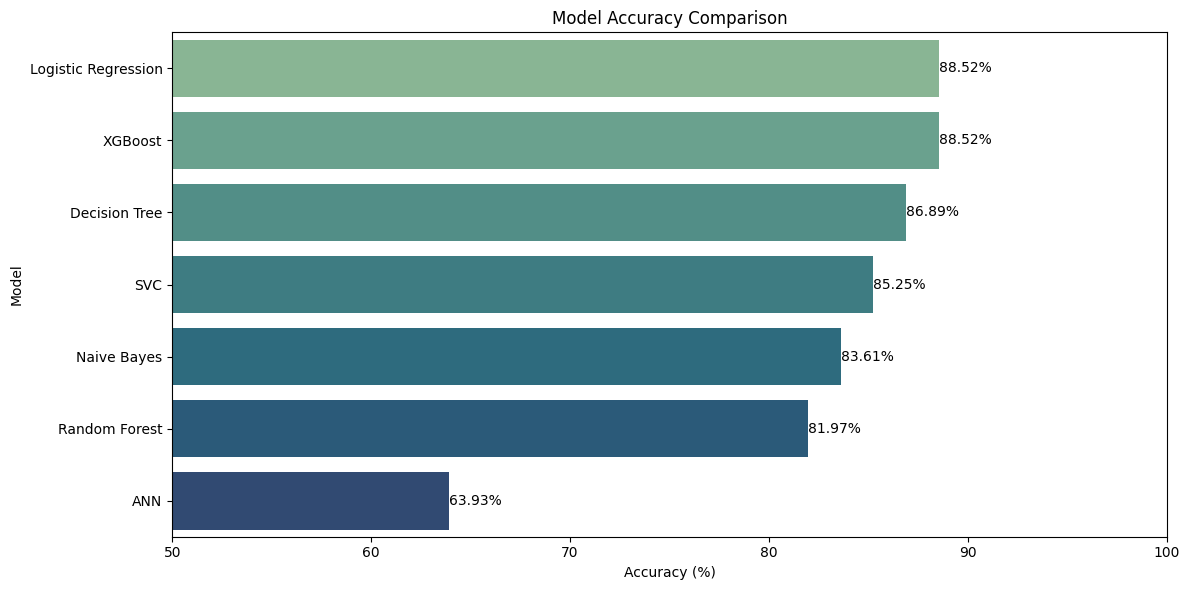

In [59]:
model_names = ['Logistic Regression','Decision Tree','Random Forest', 'XGBoost','SVC','ANN','Naive Bayes']

# Predictions
all_preds = [pred_1, pred_2, pred_3, pred_4, pred_5, pred_6, pred_7]

accuracies = [accuracy_score(y_test, p) * 100 for p in all_preds]

comparison_df = pd.DataFrame({'Model': model_names,'Accuracy (%)': accuracies})

comparison_df = comparison_df.sort_values('Accuracy (%)',ascending=False).reset_index(drop=True)

print(comparison_df)



# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Accuracy (%)',y='Model',data=comparison_df,palette="crest")

plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.xlim(50, 100)

#  Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

# Use Cross Validation for Better Output in Logistic Regression

Cross-validation is used to evaluate a model’s performance more reliably by splitting the data into multiple parts and training/testing it several times on different subsets, which helps ensure the model generalizes well to unseen data and reduces the risk of overfitting.


In [57]:
scores = cross_val_score(model1 , x,y ,cv = 5)
print("Training Score For Logistic Regressio : ",model1.score(x_train,y_train))
print("Testing Score For Logistic Regressio : ", model1.score(x_test,y_test))
print("Cross Validation score For Logistic Regression : ", scores.mean())

Training Score For Logistic Regressio :  0.8471074380165289
Testing Score For Logistic Regressio :  0.8852459016393442
Cross Validation score For Logistic Regression :  0.831584699453552


# Analysis 

**The Logistic Regression model shows consistent performance with training accuracy 0.847, testing accuracy 0.885, and cross-validation score 0.831, indicating good generalization with no significant overfitting.**


In [41]:
import pickle
pickle.dump(model1,open("model.pkl", "wb"))

**→ Why Logistic Regression model was selected?**

**It was chosen because it gives the best balanced performance across train, test, and cross-validation, and performs well on unseen data.**